# 07 - Paper-derived Quantization-aware Knowledge Distillation

This notebook implements Kim et al., **QKD: Quantization-aware Knowledge Distillation**, for the
full-INT8 ESP32 Student-120. It starts from the accepted Notebook 03 float champion, not the
rejected SPKD model.

The experiment separates four questions:

1. Does ordinary post-training quantization already preserve the float model?
2. Does hard-label QAT recover more quality than PTQ?
3. Does fixed-teacher QAT+KD outperform hard-label QAT?
4. Does the paper's complete self-studying, co-studying, and tutoring sequence add value?

## Paper-to-experiment flow

```mermaid
flowchart LR
    F[Notebook 03 float Student-120] --> P[PTQ INT8 baseline]
    F --> Q[Create QAT student]
    Q --> SS[Phase 1: self-studying<br/>hard labels only]
    SS --> HC[Hard-QAT control<br/>continue hard labels]
    SS --> AP[Fixed-teacher tutoring<br/>student CE + forward KL]
    SS --> CS[Phase 2: co-studying<br/>student and teacher update]
    CS --> TU[Phase 3: tutoring<br/>freeze adapted teacher]
    HC --> E[Full-INT8 export and parity]
    AP --> E
    TU --> E
    P --> E
    E --> G{Quality + integer-only gates}
    G -->|pass| D[ESP32-CAM and ESP32-S3 profile]
```

`hard_qat`, `fixed_teacher_qat_kd`, and `qkd_full` all receive the same eight-epoch self-study
checkpoint. The remaining twelve epochs differ only in supervision and teacher adaptation.

## Equations and paper fidelity

For network `k` and temperature `T`, the paper defines:

$$p_i(z^k;T)=\frac{\exp(z_i^k/T)}{\sum_j\exp(z_j^k/T)}.$$

Its student and teacher objectives are:

$$L^S_{KD}=L^S_{CE}+T^2 KL(p_T\Vert p_S),$$

$$L^T_{KD}=L^T_{CE}+T^2 KL(p_S\Vert p_T).$$

VWW has one Bernoulli output, so this notebook uses the exact two-class Bernoulli KL after
temperature-softening the probability-derived logits. It keeps the paper's `T=2` and unit KD
coefficient.

| Paper concept | Notebook implementation | Adaptation |
|---|---|---|
| Trainable uniform low-bit fake quantization | TFMOT full-INT8 QAT wrappers | ESP32/TFLM targets W8A8, not W2A2-W4A4 |
| Self-studying | 8 epochs hard-label QAT | Same purpose: initialize quantized student before KD |
| Co-studying | 6 epochs mutual Bernoulli KL | Teacher BN frozen and only its tail fine-tuned for small-data stability |
| Tutoring | 6 epochs with adapted teacher frozen | Paper-faithful phase transition |
| First/last layers at 8 bit | Every deployable layer at 8 bit | Required by integer-only TFLite Micro deployment |
| Trainable intervals | TFMOT learned/observed fake-quant ranges | Deployment-compatible implementation rather than reproducing custom paper kernels |

This is a concept-faithful INT8 adaptation, not a numerical reproduction of the paper's ImageNet
W2A2-W4A4 experiments.

## 1 - Fresh-kernel environment and immutable contract

In [1]:
import os, sys, subprocess
from pathlib import Path
import yaml

if "tensorflow" in sys.modules:
    raise RuntimeError(
        "Restart the kernel before running Notebook 07. TF_USE_LEGACY_KERAS must be set before TensorFlow imports."
    )

ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "configs").exists()

# Keras 3 .keras files are not directly deserializable by TFMOT's legacy-Keras runtime.
# Before importing TensorFlow here, a clean Keras 3 subprocess exports only ordered weight arrays.
# The notebook reconstructs the audited architectures under legacy Keras and verifies parity.
early_config = yaml.safe_load((ROOT / "configs/distillation_qkd_int8_120.yaml").read_text())
bridge_dir = ROOT / early_config["paths"]["artifacts"] / "compatibility_bridge"
bridge_dir.mkdir(parents=True, exist_ok=True)
bridge_sources = {
    "student": ROOT / early_config["paths"]["float_student_model"],
    "teacher": ROOT / early_config["paths"]["teacher_model"],
}
bridge_outputs = {name: bridge_dir / f"{name}_keras3_weights.npz" for name in bridge_sources}
bridge_program = (
    "import keras,numpy as np,sys; "
    "m=keras.models.load_model(sys.argv[1],compile=False); "
    "np.savez_compressed(sys.argv[2],*m.get_weights())"
)
bridge_environment = os.environ.copy()
bridge_environment.pop("TF_USE_LEGACY_KERAS", None)
for name, source in bridge_sources.items():
    output = bridge_outputs[name]
    if not output.exists() or output.stat().st_mtime < source.stat().st_mtime:
        subprocess.run(
            [sys.executable, "-c", bridge_program, str(source), str(output)],
            check=True,
            env=bridge_environment,
        )

LEGACY_STUDENT_WEIGHTS = bridge_outputs["student"]
LEGACY_TEACHER_WEIGHTS = bridge_outputs["teacher"]

os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/vww-matplotlib")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

In [2]:
# Install once from the repository root if this cell reports a missing package:
#     pip install -e '.[qat]'
try:
    import tf_keras
    import tensorflow_model_optimization as tfmot
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Notebook 07 needs the optional QAT environment. Run: pip install -e '.[qat]' then restart the kernel."
    ) from exc

import gzip, hashlib, json, random, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import display
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, roc_curve

from vww_esp32.evaluation import classification_metrics, expected_calibration_error, select_threshold
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import profile_model

assert os.environ["TF_USE_LEGACY_KERAS"] == "1"
assert tf.keras is not None and tfmot.__version__ >= "0.8"
sns.set_theme(style="whitegrid", context="talk")
print({"tensorflow": tf.__version__, "tf_keras": tf_keras.__version__, "tfmot": tfmot.__version__})

{'tensorflow': '2.20.0', 'tf_keras': '2.20.1', 'tfmot': '0.8.1'}


In [3]:
CONFIG_PATH = ROOT / "configs/distillation_qkd_int8_120.yaml"
config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
SEED = int(config["project"]["seed"])
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

ARTIFACT_DIR = ROOT / config["paths"]["artifacts"]
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
MODEL_DIR = ARTIFACT_DIR / "models"
REPORT_DIR = ARTIFACT_DIR / "reports"
FIGURE_DIR = ARTIFACT_DIR / "figures"
LOG_DIR = ARTIFACT_DIR / "logs"
for directory in (CHECKPOINT_DIR, MODEL_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TEACHER_SIZE = tuple(config["data"]["teacher_size"])
STUDENT_SIZE = tuple(config["data"]["student_size"])
BATCH_SIZE = int(config["data"]["batch_size"])
AUTOTUNE = tf.data.AUTOTUNE

RUN_TRAINING = True
REUSE_CHECKPOINTS = False
RUN_EXPORT = True

In [4]:
def sha256_file(path, chunk_bytes=1 << 20):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()

paths = {key: ROOT / value for key, value in config["paths"].items() if key != "artifacts"}
for key, path in paths.items(): assert path.exists(), f"Missing {key}: {path}"

contract = {
    "config_sha256": sha256_file(CONFIG_PATH),
    "manifest_sha256": sha256_file(paths["manifest"]),
    "teacher_sha256": sha256_file(paths["teacher_model"]),
    "float_student_sha256": sha256_file(paths["float_student_model"]),
    "paper_sha256": sha256_file(paths["qkd_paper"]),
    "legacy_student_bridge_sha256": sha256_file(LEGACY_STUDENT_WEIGHTS),
    "legacy_teacher_bridge_sha256": sha256_file(LEGACY_TEACHER_WEIGHTS),
    "seed": SEED,
    "teacher_size": TEACHER_SIZE,
    "student_size": STUDENT_SIZE,
    "batch_size": BATCH_SIZE,
    "tensorflow": tf.__version__,
    "tf_keras": tf_keras.__version__,
    "tfmot": tfmot.__version__,
}
(REPORT_DIR / "runtime_contract.json").write_text(json.dumps(contract, indent=2), encoding="utf-8")
display(pd.Series(contract, name="value"))

config_sha256                   71318369a88e388400af945b85196c2047e6e49214d822...
manifest_sha256                 6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242...
teacher_sha256                  8f8e0d7035e58abb710f8472ca5869bc14ebbd6dfea03c...
float_student_sha256            88e98014baab353bb6eb6df9280e4f993de34adf75dcb9...
paper_sha256                    a3efc0f1b1f3ebfb49b82d53ba57ed8d3ecf12d16ed7d6...
legacy_student_bridge_sha256    b30f26e8da53d72d9800d1b3164b5453c85eda66d3bca3...
legacy_teacher_bridge_sha256    9f0eff44675f9832e5002b89e1416825b9019e1e87a1cd...
seed                                                                           42
teacher_size                                                           (160, 160)
student_size                                                           (120, 120)
batch_size                                                                     32
tensorflow                                                                 2.20.0
tf_keras        

## 2 - Frozen split and shared RGB views

In [5]:
manifest = pd.read_csv(paths["manifest"])
assert {"image_id", "image_path", "split", "label"}.issubset(manifest.columns)
assert manifest["image_id"].is_unique
manifest["image_path"] = manifest["image_path"].map(
    lambda value: str((ROOT / value).resolve()) if not Path(value).is_absolute() else value
)
assert manifest["image_path"].map(lambda value: Path(value).exists()).all()
splits = {name: frame.reset_index(drop=True) for name, frame in manifest.groupby("split", sort=False)}
dataset_summary = pd.DataFrame([
    {"split": name, "samples": len(frame), "person_fraction": float(frame.label.mean())}
    for name, frame in splits.items()
])
dataset_summary.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)
display(dataset_summary)

,split,samples,person_fraction
0,test,2000,0.4905
1,train,12000,0.5000
2,val,2000,0.4945


In [6]:
def build_augmentation(seed):
    settings = config["augmentation"]
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", seed=seed),
        tf.keras.layers.RandomTranslation(
            settings["translation_fraction"], settings["translation_fraction"],
            fill_mode="reflect", seed=seed + 1,
        ),
        tf.keras.layers.RandomBrightness(
            settings["brightness_delta"], value_range=(0.0, 1.0), seed=seed + 2,
        ),
        tf.keras.layers.RandomContrast(settings["contrast_factor"], seed=seed + 3),
        tf.keras.layers.Lambda(
            lambda image: tf.image.random_saturation(
                image, 1 - settings["saturation_delta"],
                1 + settings["saturation_delta"], seed=seed + 4,
            ),
            name="random_saturation_rgb",
        ),
        tf.keras.layers.GaussianNoise(settings["sensor_noise_stddev"], seed=seed + 5),
    ], name=f"shared_rgb_augmentation_{seed}")

In [7]:
def decode_rgb(path):
    image = tf.io.decode_image(tf.io.read_file(path), channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    return tf.cast(image, tf.float32)

In [8]:
def make_dataset(frame, training, seed, batch_size=BATCH_SIZE):
    augmentation = build_augmentation(seed)
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame.image_path.astype(str), frame.label.astype("float32"))
    )

    if training:
        dataset = dataset.shuffle(
            min(len(frame), 4096), 
            seed=seed, 
            reshuffle_each_iteration=True
        )

    def prepare(path, label):
        base = tf.image.resize_with_pad(decode_rgb(path), *TEACHER_SIZE, antialias=True) / 255.0
        if training: 
            base = augmentation(base, training=True)
        base = tf.clip_by_value(base, 0.0, 1.0)
        return {
            "teacher_image": base * 255.0,
            "student_image": tf.image.resize(base, STUDENT_SIZE, antialias=True) * 255.0,
        }, tf.reshape(label, (1,))
    return dataset.map(prepare, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

In [9]:
def make_student_eval_dataset(frame, batch_size=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame.image_path.astype(str), frame.label.astype("float32"))
    )
    return dataset.map(
        lambda path, label: (tf.image.resize_with_pad(decode_rgb(path), *STUDENT_SIZE, antialias=True), label),
        num_parallel_calls=AUTOTUNE,
    ).batch(batch_size).prefetch(AUTOTUNE)

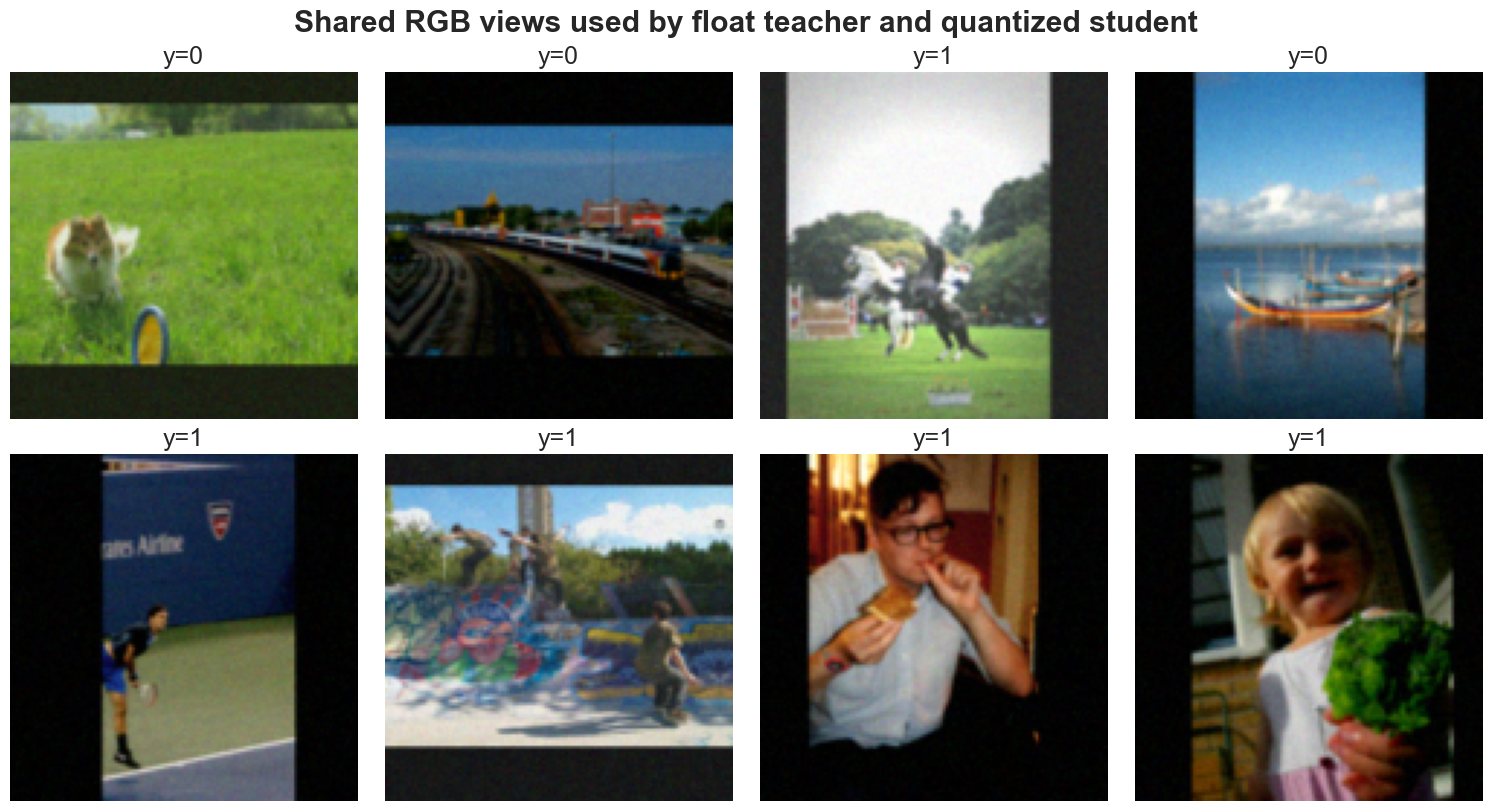

In [10]:
preview_inputs, preview_labels = next(iter(make_dataset(splits["train"].iloc[:8], True, SEED, 8)))
fig, axes = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
for index, axis in enumerate(axes.flat):
    axis.imshow(np.clip(preview_inputs["student_image"][index] / 255.0, 0, 1))
    axis.set_title(f"y={int(preview_labels[index, 0])}")
    axis.axis("off")
fig.suptitle("Shared RGB views used by float teacher and quantized student", fontweight="bold")
fig.savefig(FIGURE_DIR / "shared_rgb_views.png", dpi=180)
plt.show()

## 3 - Float anchors and pre-quantization audit

In [11]:
def ordered_npz_weights(path):
    archive = np.load(path)
    return [
        archive[f"arr_{index}"] for index in range(len(archive.files))
    ]

FLOAT STUDENT

In [12]:
def build_float_student():
    image = tf.keras.Input((*STUDENT_SIZE, 3), name="image")
    normalized = tf.keras.layers.Rescaling(1 / 127.5, offset=-1, name="normalize")(image)

    backbone = tf.keras.applications.MobileNet(
        input_tensor=normalized, 
        input_shape=(*STUDENT_SIZE, 3), 
        alpha=0.25,
        include_top=False, 
        weights=None,
    )
    features = tf.keras.layers.GlobalAveragePooling2D(name="global_average")(backbone.output)
    features = tf.keras.layers.Dropout(0.1, name="student_dropout")(features)

    logits = tf.keras.layers.Dense(
        1, kernel_regularizer=tf.keras.regularizers.l2(1e-5), name="person_logit"
    )(features)
    probability = tf.keras.layers.Activation("sigmoid", name="person_probability")(logits)

    model = tf.keras.Model(image, probability, name="same_view_lambda0_probability")
    model.set_weights(
        ordered_npz_weights(LEGACY_STUDENT_WEIGHTS)
    )

    return model

FLOAT TEACHER

In [13]:
def build_float_teacher():
    image = tf.keras.Input((*TEACHER_SIZE, 3), name="image")
    normalized = tf.keras.layers.Rescaling(
        1 / 127.5, offset=-1, name="normalize", trainable=False
    )(image)

    backbone = tf.keras.applications.MobileNet(
        input_tensor=normalized, 
        input_shape=(*TEACHER_SIZE, 3), 
        alpha=0.50,
        include_top=False,
        weights=None,
    )
    features = tf.keras.layers.GlobalAveragePooling2D(name="global_average")(backbone.output)
    features = tf.keras.layers.Dropout(0.2, name="teacher_dropout")(features)

    probability = tf.keras.layers.Dense(
        1, activation="sigmoid", kernel_regularizer=tf.keras.regularizers.l2(1e-5),
        name="person_probability",
    )(features)

    model = tf.keras.Model(image, probability, name="vww_teacher_mobilenetv1_160_a050")
    model.set_weights(
        ordered_npz_weights(LEGACY_TEACHER_WEIGHTS)
    )

    return model

In [14]:
teacher_original = build_float_teacher()
float_student = build_float_student()
teacher_original.trainable = False

In [15]:
assert teacher_original.input_shape == (None, *TEACHER_SIZE, 3)
assert float_student.input_shape == (None, *STUDENT_SIZE, 3)
assert teacher_original.count_params() == 830049
assert float_student.count_params() == 218801

float_quality = pd.read_csv(paths["float_student_quality"])
float_champion_record = float_quality.set_index("model").loc["same_view_lambda0"]
display(float_champion_record)

samples                                        2000
threshold                                     0.385
accuracy                                     0.7815
precision                                  0.777551
recall                                     0.776758
f1                                         0.777155
roc_auc                                    0.862603
pr_auc                                     0.865103
specificity                                0.786065
confusion_matrix           [[801, 218], [219, 762]]
positive_prevalence                          0.4905
predicted_positive_rate                        0.49
ece_10                                     0.039434
Name: same_view_lambda0, dtype: object

In [16]:
layer_table, liveness, static_profile = profile_model(
    float_student, 
    batch_size=1, 
    training_batch_size=BATCH_SIZE
)
layer_table.to_csv(REPORT_DIR / "float_student_layer_profile.csv", index=False)
liveness.to_csv(REPORT_DIR / "float_student_activation_liveness.csv", index=False)
(REPORT_DIR / "float_student_static_profile.json").write_text(
    json.dumps(static_profile, indent=2), encoding="utf-8"
)
display(pd.Series(static_profile))

model_name                                                                 same_view_lambda0_probability
layers                                                                                                91
parameters                                                                                        218801
trainable_parameters                                                                              213329
non_trainable_parameters                                                                            5472
float32_weight_bytes                                                                              875204
global_weight_sparsity                                                                               0.0
global_weight_near_zero_fraction                                                                0.004127
global_kernel_sparsity                                                                               0.0
global_kernel_near_zero_fraction                       

## 4 - Build a deployment-compatible W8A8 QAT student

In [17]:
QUANTIZABLE_TYPES = (
    tf.keras.layers.Conv2D,
    tf.keras.layers.DepthwiseConv2D,
    tf.keras.layers.Dense,
    tf.keras.layers.ReLU,
    tf.keras.layers.Activation,
)

In [18]:
def clone_layer(layer):
    return layer.__class__.from_config(layer.get_config())

In [19]:
def annotate_for_int8(layer):
    cloned = clone_layer(layer)
    if isinstance(cloned, QUANTIZABLE_TYPES):
        return tfmot.quantization.keras.quantize_annotate_layer(cloned)
    return cloned

In [20]:
def build_qat_student():
    source = build_float_student()
    annotated = tf.keras.models.clone_model(
        source, 
        clone_function=annotate_for_int8
    )
    annotated.set_weights(source.get_weights())
    
    with tfmot.quantization.keras.quantize_scope():
        qat = tfmot.quantization.keras.quantize_apply(annotated)
    # Preserve the calibrated moving statistics from the float champion.
    # Updating BatchNorm on this compact subset makes QAT less stable and
    # complicates the Conv-BN folding used by the integer deployment graph.
    for layer in qat.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    return qat

In [21]:
tf.keras.utils.set_random_seed(SEED)
qat_probe = build_qat_student()
probe_output = qat_probe(tf.zeros((2, *STUDENT_SIZE, 3), tf.float32), training=False)
assert probe_output.shape == (2, 1)
assert np.isfinite(np.asarray(probe_output)).all()
print({"qat_parameters_including_quantizer_state": qat_probe.count_params(), "output_shape": probe_output.shape})

{'qat_parameters_including_quantizer_state': 221992, 'output_shape': TensorShape([2, 1])}


In [22]:
def quantizer_inventory(model):
    rows = []
    for variable in model.weights:
        name = variable.name.lower()
        if any(token in name for token in ("min", "max", "scale")) and "quant" in name:
            values = np.asarray(variable)
            rows.append({
                "variable": variable.name,
                "shape": str(tuple(values.shape)),
                "minimum": float(values.min()),
                "maximum": float(values.max()),
                "mean": float(values.mean()),
                "trainable": bool(variable.trainable),
            })
    return pd.DataFrame(rows)

initial_quantizers = quantizer_inventory(qat_probe)
initial_quantizers.to_csv(REPORT_DIR / "initial_quantizer_inventory.csv", index=False)
display(initial_quantizers.head(20))
assert len(initial_quantizers) > 0, "No fake-quant state found; QAT construction is invalid."

,variable,shape,minimum,maximum,mean,trainable
0,quant_conv1/kernel_min:0,"(8,)",-6.0,-6.0,-6.0,False
1,quant_conv1/kernel_max:0,"(8,)",6.0,6.0,6.0,False
2,quant_conv1/post_activation_min:0,(),-6.0,-6.0,-6.0,False
3,quant_conv1/post_activation_max:0,(),6.0,6.0,6.0,False
4,quant_conv1_relu/output_min:0,(),-6.0,-6.0,-6.0,False
5,quant_conv1_relu/output_max:0,(),6.0,6.0,6.0,False
6,quant_conv_dw_1/depthwise_kernel_min:0,"(1,)",-6.0,-6.0,-6.0,False
7,quant_conv_dw_1/depthwise_kernel_max:0,"(1,)",6.0,6.0,6.0,False
8,quant_conv_dw_1/post_activation_min:0,(),-6.0,-6.0,-6.0,False
9,quant_conv_dw_1/post_activation_max:0,(),6.0,6.0,6.0,False


### QAT construction gate

Do not continue if the probe lacks quantization wrappers or fake-quant range state. The Keras model
will contain training-only quantization simulation; the exported TFLite model must later contain
only supported integer inference operators.

## 5 - Bernoulli KL divergence for binary VWW

The paper writes distillation with categorical KL divergence. VWW has one sigmoid output rather
than a multi-class softmax: a model predicts $p=P(\text{person}\mid x)$ and therefore
$1-p=P(\text{no person}\mid x)$. Each output is consequently a Bernoulli distribution
$P=(p,1-p)$, so both the person and no-person terms must participate in distillation.

For target probability $p$ and predicted probability $q$, the binary KL divergence is

$$
D_{\mathrm{KL}}\!\left(\operatorname{Bern}(p)\,\|\,\operatorname{Bern}(q)\right)
=p\log\frac{p}{q}+(1-p)\log\frac{1-p}{1-q}.
$$

This is the two-class categorical definition $\sum_c p_c\log(p_c/q_c)$ after substituting
$(p_1,p_0)=(p,1-p)$ and $(q_1,q_0)=(q,1-q)$. KL is non-negative and equals zero only when
$p=q$. It is directional: $D_{\mathrm{KL}}(P\|Q)\neq D_{\mathrm{KL}}(Q\|P)$ in general.

### Temperature-softened binary probabilities

Because the saved networks expose sigmoid probabilities, recover the logit
$z=\log[p/(1-p)]$ and soften it with temperature $T$:

$$
p^{(T)}=\sigma\!\left(\frac{\operatorname{logit}(p)}{T}\right),
\qquad T=2.
$$

For $T>1$, probabilities move toward $0.5$, exposing the teacher's uncertainty instead of only
its hard decision. Multiplication by $T^2$ compensates for the gradient shrinkage introduced by
temperature smoothing, following the paper's QKD objective.

### Direction used by each QKD update

The quantized student minimizes

$$
\mathcal L_S=\operatorname{BCE}(y,p_S)+\lambda T^2
D_{\mathrm{KL}}\!\left(\operatorname{Bern}(p_T^{(T)})\,\|\,
\operatorname{Bern}(p_S^{(T)})\right)+\mathcal L_{\mathrm{reg}}.
$$

During co-studying only, the teacher receives the reverse direction

$$
\mathcal L_T=\operatorname{BCE}(y,p_T)+\lambda T^2
D_{\mathrm{KL}}\!\left(\operatorname{Bern}(p_S^{(T)})\,\|\,
\operatorname{Bern}(p_T^{(T)})\right)+\mathcal L_{\mathrm{reg}}.
$$

`stop_gradient` is applied to the distribution acting as the target in each direction. Thus the
student KL updates only the student, while reverse KL updates only the teacher. Self-studying has
no KL term; fixed-teacher KD and tutoring use only the forward teacher-to-student term. The code
below implements these equations directly rather than hiding them inside a Keras loss object.

In [23]:
TEMPERATURE = float(config["qkd"]["temperature"])
KD_WEIGHT = float(config["qkd"]["kd_weight"])
assert TEMPERATURE == 2.0, "The paper anchor uses T=2."

In [24]:
def probability_to_logit(
        probability, 
        epsilon=1e-6
):
    probability = tf.clip_by_value(
        tf.cast(probability, tf.float32), 
        epsilon, 
        1 - epsilon
    )
    return tf.math.log(probability) - tf.math.log1p(-probability)

SOFT

In [25]:
def soften_probability(
        probability, 
        temperature=TEMPERATURE
):
    return tf.sigmoid(
        probability_to_logit(probability) / temperature
    )

BERNOULLI KL DIVERGENCE

In [26]:
def bernoulli_kl(
        target_probability, 
        predicted_probability, 
        epsilon=1e-6
):
    target = tf.clip_by_value(
        tf.cast(target_probability, tf.float32), 
        epsilon, 
        1 - epsilon
    )
    predicted = tf.clip_by_value(
        tf.cast(predicted_probability, tf.float32), 
        epsilon, 
        1 - epsilon
    )
    return tf.reduce_mean(
        target * tf.math.log(target / predicted) + (1 - target) * tf.math.log((1 - target) / (1 - predicted))
    )

HARD

In [27]:
def hard_bce(
        labels, 
        probability
):
    labels = tf.reshape(tf.cast(labels, tf.float32), (-1, 1))
    return tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(labels, probability)
    )

In [28]:
probe_probability = tf.constant([[0.1], [0.4], [0.8]], tf.float32)
assert float(bernoulli_kl(probe_probability, probe_probability)) < 1e-7
assert np.allclose(
    soften_probability(probe_probability, temperature=1.0).numpy(),
    probe_probability.numpy(), atol=1e-6,
)
assert np.all(np.abs(soften_probability(probe_probability).numpy() - 0.5) <= np.abs(probe_probability.numpy() - 0.5))
print("Binary QKD invariants passed")

Binary QKD invariants passed


## 6 - Paper phases: trainers, checkpoints, and common budget

In [ ]:
def configure_teacher_for_co_study(model):
    convolution_names = [layer.name for layer in model.layers if layer.name.startswith("conv_")]
    count = int(config["qkd"]["teacher_fine_tune_last_layers"])
    selected = set(convolution_names[max(0, len(convolution_names) - count):])
    for layer in model.layers:
        layer.trainable = (
            layer.name in selected or layer.name == "person_probability"
        ) and not isinstance(layer, tf.keras.layers.BatchNormalization)
    return model


In [ ]:
class EpochTimer(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None): self.started = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None): logs["epoch_seconds"] = time.perf_counter() - self.started

class BestPhaseWeights(tf.keras.callbacks.Callback):
    def __init__(self, student_path, teacher_path=None):
        super().__init__(); self.student_path = Path(student_path); self.teacher_path = teacher_path; self.best = -np.inf
    def on_epoch_end(self, epoch, logs=None):
        value = (logs or {}).get(config["training"]["monitor"])
        if value is not None and float(value) > self.best:
            self.best = float(value)
            self.model.student.save_weights(self.student_path)
            if self.teacher_path is not None:
                self.model.teacher.save_weights(self.teacher_path)

def phase_callbacks(name, student_path, teacher_path=None):
    return [
        EpochTimer(), 
        BestPhaseWeights(student_path, teacher_path),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=config["training"]["monitor"], 
            mode="max", 
            factor=0.3,
            patience=int(config["training"]["reduce_lr_patience"]), 
            min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(LOG_DIR / f"{name}.csv"),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

In [30]:
class QKDTrainer(tf.keras.Model):
    def __init__(self, student, teacher, phase):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.phase = phase
        self.use_kd = phase in {
            "fixed_teacher", 
            "co_study", 
            "tutoring"
        }
        self.update_teacher = phase == "co_study"
        tracked = [
            "loss", 
            "student_hard_loss", 
            "student_kd_loss", 
            "teacher_loss", 
            "teacher_hard_loss", 
            "reverse_kd_loss"
        ]
        self.track = {name: tf.keras.metrics.Mean(name=name) for name in tracked}
        self.quality = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ]

    @property
    def metrics(self): 
        return [*self.track.values(), *self.quality]

    def compile(self, student_optimizer, teacher_optimizer=None):
        super().compile(optimizer=student_optimizer)
        self.student_optimizer = student_optimizer
        self.teacher_optimizer = teacher_optimizer

    def _forward_losses(
            self, 
            inputs, 
            labels, 
            training
    ):
        student_probability = self.student(
            inputs["student_image"], 
            training=training
        )
        student_hard = hard_bce(
            labels, 
            student_probability
        )
        zero = tf.constant(0.0, tf.float32)
        teacher_probability = None
        student_kd = zero
        teacher_hard = zero
        reverse_kd = zero

        if self.use_kd:
            teacher_probability = self.teacher(
                inputs["teacher_image"], 
                training=self.update_teacher and training
            )
            soft_student = soften_probability(student_probability)
            soft_teacher = soften_probability(teacher_probability)
            student_kd = TEMPERATURE**2 * bernoulli_kl(
                tf.stop_gradient(soft_teacher), 
                soft_student
            )

            if self.update_teacher:
                teacher_hard = hard_bce(
                    labels, 
                    teacher_probability
                )
                reverse_kd = TEMPERATURE**2 * bernoulli_kl(
                    tf.stop_gradient(soft_student), 
                    soft_teacher
                )

        student_reg = tf.add_n(self.student.losses) if self.student.losses else zero
        teacher_reg = tf.add_n(self.teacher.losses) if self.update_teacher and self.teacher.losses else zero
        student_total = student_hard + KD_WEIGHT * student_kd + student_reg
        teacher_total = teacher_hard + KD_WEIGHT * reverse_kd + teacher_reg

        return student_probability, student_total, student_hard, student_kd, teacher_total, teacher_hard, reverse_kd

    def train_step(self, data):
        inputs, labels = data

        with tf.GradientTape(persistent=self.update_teacher) as tape:
            values = self._forward_losses(inputs, labels, training=True)

        probability, total, hard, kd, teacher_total, teacher_hard, reverse_kd = values
        student_gradients = tape.gradient(total, self.student.trainable_variables)

        self.student_optimizer.apply_gradients([
            (gradient, variable) for gradient, variable in zip(student_gradients, self.student.trainable_variables)
            if gradient is not None
        ])

        if self.update_teacher:
            teacher_gradients = tape.gradient(teacher_total, self.teacher.trainable_variables)
            self.teacher_optimizer.apply_gradients([
                (gradient, variable) for gradient, variable in zip(teacher_gradients, self.teacher.trainable_variables)
                if gradient is not None
            ])
            del tape
        tracked = {
            "loss": total, 
            "student_hard_loss": hard, 
            "student_kd_loss": kd,
            "teacher_loss": teacher_total, 
            "teacher_hard_loss": teacher_hard, 
            "reverse_kd_loss": reverse_kd,
        }
        for name, value in tracked.items(): self.track[name].update_state(value)
        for metric in self.quality: metric.update_state(tf.reshape(labels, (-1, 1)), probability)
        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        inputs, labels = data
        probability, total, hard, kd, teacher_total, teacher_hard, reverse_kd = self._forward_losses(inputs, labels, training=False)
        tracked = {
            "loss": total, 
            "student_hard_loss": hard, 
            "student_kd_loss": kd,
            "teacher_loss": teacher_total, 
            "teacher_hard_loss": teacher_hard, 
            "reverse_kd_loss": reverse_kd,
        }
        for name, value in tracked.items(): self.track[name].update_state(value)
        for metric in self.quality: metric.update_state(tf.reshape(labels, (-1, 1)), probability)
        return {metric.name: metric.result() for metric in self.metrics}

![](qkd_process.png)

### Phase 1 - Self-studying (SS)

In [31]:
INITIAL_QAT = CHECKPOINT_DIR / "initial_qat.weights.h5"
SELF_STUDY = CHECKPOINT_DIR / "self_study.weights.h5"

In [32]:
if not INITIAL_QAT.exists() or not REUSE_CHECKPOINTS:
    tf.keras.utils.set_random_seed(SEED)
    initial_student = build_qat_student()
    initial_student.save_weights(INITIAL_QAT)

if RUN_TRAINING and not (REUSE_CHECKPOINTS and SELF_STUDY.exists()):
    student = build_qat_student()
    student.load_weights(INITIAL_QAT)
    trainer = QKDTrainer(
        student, 
        teacher_original, 
        phase="self_study"
    )
    trainer.compile(
        student_optimizer=tf.keras.optimizers.legacy.Adam(config["training"]["student_learning_rate"])
    )
    trainer.fit(
        make_dataset(splits["train"], True, SEED),
        validation_data=make_dataset(splits["val"], False, SEED),
        epochs=int(config["training"]["self_study_epochs"]),
        callbacks=phase_callbacks("self_study", SELF_STUDY),
    )
assert SELF_STUDY.exists()

Epoch 1/8
375/375 [==============================] - 46s 116ms/step - loss: 0.7000 - student_hard_loss: 0.7000 - student_kd_loss: 0.0000e+00 - teacher_loss: 0.0000e+00 - teacher_hard_loss: 0.0000e+00 - reverse_kd_loss: 0.0000e+00 - accuracy: 0.4988 - precision: 0.4978 - recall: 0.2783 - pr_auc: 0.5029 - val_loss: 0.6908 - val_student_hard_loss: 0.6908 - val_student_kd_loss: 0.0000e+00 - val_teacher_loss: 0.0000e+00 - val_teacher_hard_loss: 0.0000e+00 - val_reverse_kd_loss: 0.0000e+00 - val_accuracy: 0.5240 - val_precision: 0.5157 - val_recall: 0.6127 - val_pr_auc: 0.5500 - epoch_seconds: 45.8524 - lr: 1.0000e-05
Epoch 2/8
375/375 [==============================] - 40s 106ms/step - loss: 0.6771 - student_hard_loss: 0.6771 - student_kd_loss: 0.0000e+00 - teacher_loss: 0.0000e+00 - teacher_hard_loss: 0.0000e+00 - reverse_kd_loss: 0.0000e+00 - accuracy: 0.5661 - precision: 0.5709 - recall: 0.5323 - pr_auc: 0.5862 - val_loss: 0.6459 - val_student_hard_loss: 0.6459 - val_student_kd_loss: 0.0

### Controlled branches after the shared self-study checkpoint

In [33]:
HARD_QAT = CHECKPOINT_DIR / "hard_qat.weights.h5"
FIXED_KD = CHECKPOINT_DIR / "fixed_teacher_qat_kd.weights.h5"
CO_STUDENT = CHECKPOINT_DIR / "co_study_student.weights.h5"
CO_TEACHER = CHECKPOINT_DIR / "co_study_teacher.weights.h5"
FULL_QKD = CHECKPOINT_DIR / "qkd_full.weights.h5"

In [34]:
remaining_epochs = int(config["training"]["co_study_epochs"]) + int(config["training"]["tutoring_epochs"])

In [35]:
def train_from_self_study(
        name, 
        phase, 
        output_path, 
        epochs
):
    student = build_qat_student()
    student.load_weights(SELF_STUDY)
    teacher = build_float_teacher()
    teacher.trainable = False

    if RUN_TRAINING and not (REUSE_CHECKPOINTS and output_path.exists()):
        trainer = QKDTrainer(
            student, 
            teacher, 
            phase=phase
        )
        trainer.compile(
            student_optimizer=tf.keras.optimizers.legacy.Adam(config["training"]["student_learning_rate"])
        )
        trainer.fit(
            make_dataset(splits["train"], True, SEED),
            validation_data=make_dataset(splits["val"], False, SEED),
            epochs=epochs,
            callbacks=phase_callbacks(name, output_path),
        )
    assert output_path.exists()

In [36]:
train_from_self_study("hard_qat", "hard_qat", HARD_QAT, remaining_epochs)
train_from_self_study("fixed_teacher_qat_kd", "fixed_teacher", FIXED_KD, remaining_epochs)

Epoch 1/12
375/375 [==============================] - 43s 108ms/step - loss: 0.4448 - student_hard_loss: 0.4448 - student_kd_loss: 0.0000e+00 - teacher_loss: 0.0000e+00 - teacher_hard_loss: 0.0000e+00 - reverse_kd_loss: 0.0000e+00 - accuracy: 0.7900 - precision: 0.8083 - recall: 0.7603 - pr_auc: 0.8808 - val_loss: 0.4720 - val_student_hard_loss: 0.4720 - val_student_kd_loss: 0.0000e+00 - val_teacher_loss: 0.0000e+00 - val_teacher_hard_loss: 0.0000e+00 - val_reverse_kd_loss: 0.0000e+00 - val_accuracy: 0.7710 - val_precision: 0.7746 - val_recall: 0.7573 - val_pr_auc: 0.8589 - epoch_seconds: 42.4301 - lr: 1.0000e-05
Epoch 2/12
375/375 [==============================] - 40s 107ms/step - loss: 0.4432 - student_hard_loss: 0.4432 - student_kd_loss: 0.0000e+00 - teacher_loss: 0.0000e+00 - teacher_hard_loss: 0.0000e+00 - reverse_kd_loss: 0.0000e+00 - accuracy: 0.7859 - precision: 0.8062 - recall: 0.7528 - pr_auc: 0.8823 - val_loss: 0.4665 - val_student_hard_loss: 0.4664 - val_student_kd_loss: 0

### Phase 2 - Co-studying (CS): adapt both networks

In [37]:
if RUN_TRAINING and not (REUSE_CHECKPOINTS and CO_STUDENT.exists() and CO_TEACHER.exists()):
    student = build_qat_student()
    student.load_weights(SELF_STUDY)
    
    teacher = configure_teacher_for_co_study(
        build_float_teacher()
    )
    trainer = QKDTrainer(
        student, 
        teacher, 
        phase="co_study"
    )
    trainer.compile(
        student_optimizer=tf.keras.optimizers.legacy.Adam(config["training"]["student_learning_rate"]),
        teacher_optimizer=tf.keras.optimizers.legacy.Adam(config["training"]["teacher_learning_rate"]),
    )
    trainer.fit(
        make_dataset(splits["train"], True, SEED),
        validation_data=make_dataset(splits["val"], False, SEED),
        epochs=int(config["training"]["co_study_epochs"]),
        callbacks=phase_callbacks("co_study", CO_STUDENT, CO_TEACHER),
    )
assert CO_STUDENT.exists() and CO_TEACHER.exists()

Epoch 1/6
375/375 [==============================] - 150s 391ms/step - loss: 0.5751 - student_hard_loss: 0.4518 - student_kd_loss: 0.1233 - teacher_loss: 0.5055 - teacher_hard_loss: 0.3769 - reverse_kd_loss: 0.1287 - accuracy: 0.7892 - precision: 0.8102 - recall: 0.7553 - pr_auc: 0.8790 - val_loss: 0.5883 - val_student_hard_loss: 0.4701 - val_student_kd_loss: 0.1182 - val_teacher_loss: 0.4831 - val_teacher_hard_loss: 0.3597 - val_reverse_kd_loss: 0.1233 - val_accuracy: 0.7725 - val_precision: 0.7846 - val_recall: 0.7442 - val_pr_auc: 0.8589 - epoch_seconds: 149.2311 - lr: 1.0000e-05
Epoch 2/6
375/375 [==============================] - 153s 408ms/step - loss: 0.5474 - student_hard_loss: 0.4468 - student_kd_loss: 0.1006 - teacher_loss: 0.4824 - teacher_hard_loss: 0.3795 - reverse_kd_loss: 0.1028 - accuracy: 0.7906 - precision: 0.8148 - recall: 0.7522 - pr_auc: 0.8841 - val_loss: 0.5721 - val_student_hard_loss: 0.4636 - val_student_kd_loss: 0.1086 - val_teacher_loss: 0.4698 - val_teacher_

### Phase 3 - Tutoring (TU): freeze the adapted teacher

In [38]:
if RUN_TRAINING and not (REUSE_CHECKPOINTS and FULL_QKD.exists()):
    student = build_qat_student()
    student.load_weights(CO_STUDENT)

    adapted_teacher = build_float_teacher()
    adapted_teacher.load_weights(CO_TEACHER)
    adapted_teacher.trainable = False

    trainer = QKDTrainer(
        student, 
        adapted_teacher, 
        phase="tutoring"
    )
    trainer.compile(
        student_optimizer=tf.keras.optimizers.legacy.Adam(config["training"]["student_learning_rate"])
    )
    trainer.fit(
        make_dataset(splits["train"], True, SEED),
        validation_data=make_dataset(splits["val"], False, SEED),
        epochs=int(config["training"]["tutoring_epochs"]),
        callbacks=phase_callbacks("tutoring", FULL_QKD),
    )
assert FULL_QKD.exists()

weight_paths = {
    "hard_qat": HARD_QAT,
    "fixed_teacher_qat_kd": FIXED_KD,
    "qkd_full": FULL_QKD,
}

Epoch 1/6
375/375 [==============================] - 107s 260ms/step - loss: 0.5335 - student_hard_loss: 0.4453 - student_kd_loss: 0.0882 - teacher_loss: 0.0000e+00 - teacher_hard_loss: 0.0000e+00 - reverse_kd_loss: 0.0000e+00 - accuracy: 0.7902 - precision: 0.8143 - recall: 0.7518 - pr_auc: 0.8836 - val_loss: 0.5713 - val_student_hard_loss: 0.4639 - val_student_kd_loss: 0.1074 - val_teacher_loss: 0.0000e+00 - val_teacher_hard_loss: 0.0000e+00 - val_reverse_kd_loss: 0.0000e+00 - val_accuracy: 0.7775 - val_precision: 0.7918 - val_recall: 0.7462 - val_pr_auc: 0.8650 - epoch_seconds: 106.6084 - lr: 1.0000e-05
Epoch 2/6
375/375 [==============================] - 76s 202ms/step - loss: 0.5294 - student_hard_loss: 0.4425 - student_kd_loss: 0.0870 - teacher_loss: 0.0000e+00 - teacher_hard_loss: 0.0000e+00 - reverse_kd_loss: 0.0000e+00 - accuracy: 0.7942 - precision: 0.8191 - recall: 0.7552 - pr_auc: 0.8869 - val_loss: 0.5705 - val_student_hard_loss: 0.4642 - val_student_kd_loss: 0.1063 - val_

## 7 - Optimization and teacher-adaptation audit

In [39]:
history_frames = []
phase_order = ["self_study", "hard_qat", "fixed_teacher_qat_kd", "co_study", "tutoring"]
for name in phase_order:
    path = LOG_DIR / f"{name}.csv"
    if path.exists():
        frame = pd.read_csv(path); frame["run"] = name; frame["epoch_index"] = np.arange(1, len(frame) + 1)
        history_frames.append(frame)
history = pd.concat(history_frames, ignore_index=True)
history.to_csv(REPORT_DIR / "training_history.csv", index=False)
runtime = history.groupby("run", as_index=False).agg(
    epochs=("epoch_index", "max"), best_val_pr_auc=("val_pr_auc", "max"),
    final_val_pr_auc=("val_pr_auc", "last"), runtime_seconds=("epoch_seconds", "sum"),
)
runtime["runtime_minutes"] = runtime.runtime_seconds / 60
runtime.to_csv(REPORT_DIR / "training_runtime_summary.csv", index=False)
display(runtime)

,run,epochs,best_val_pr_auc,final_val_pr_auc,runtime_seconds,runtime_minutes
0,co_study,6,0.865966,0.864683,764.715140,12.745252
1,fixed_teacher_qat_kd,12,0.868383,0.864760,1293.374975,21.556250
2,hard_qat,12,0.868430,0.865802,896.063916,14.934399
3,self_study,8,0.856845,0.856845,480.517165,8.008619
4,tutoring,6,0.865978,0.865978,566.526200,9.442103


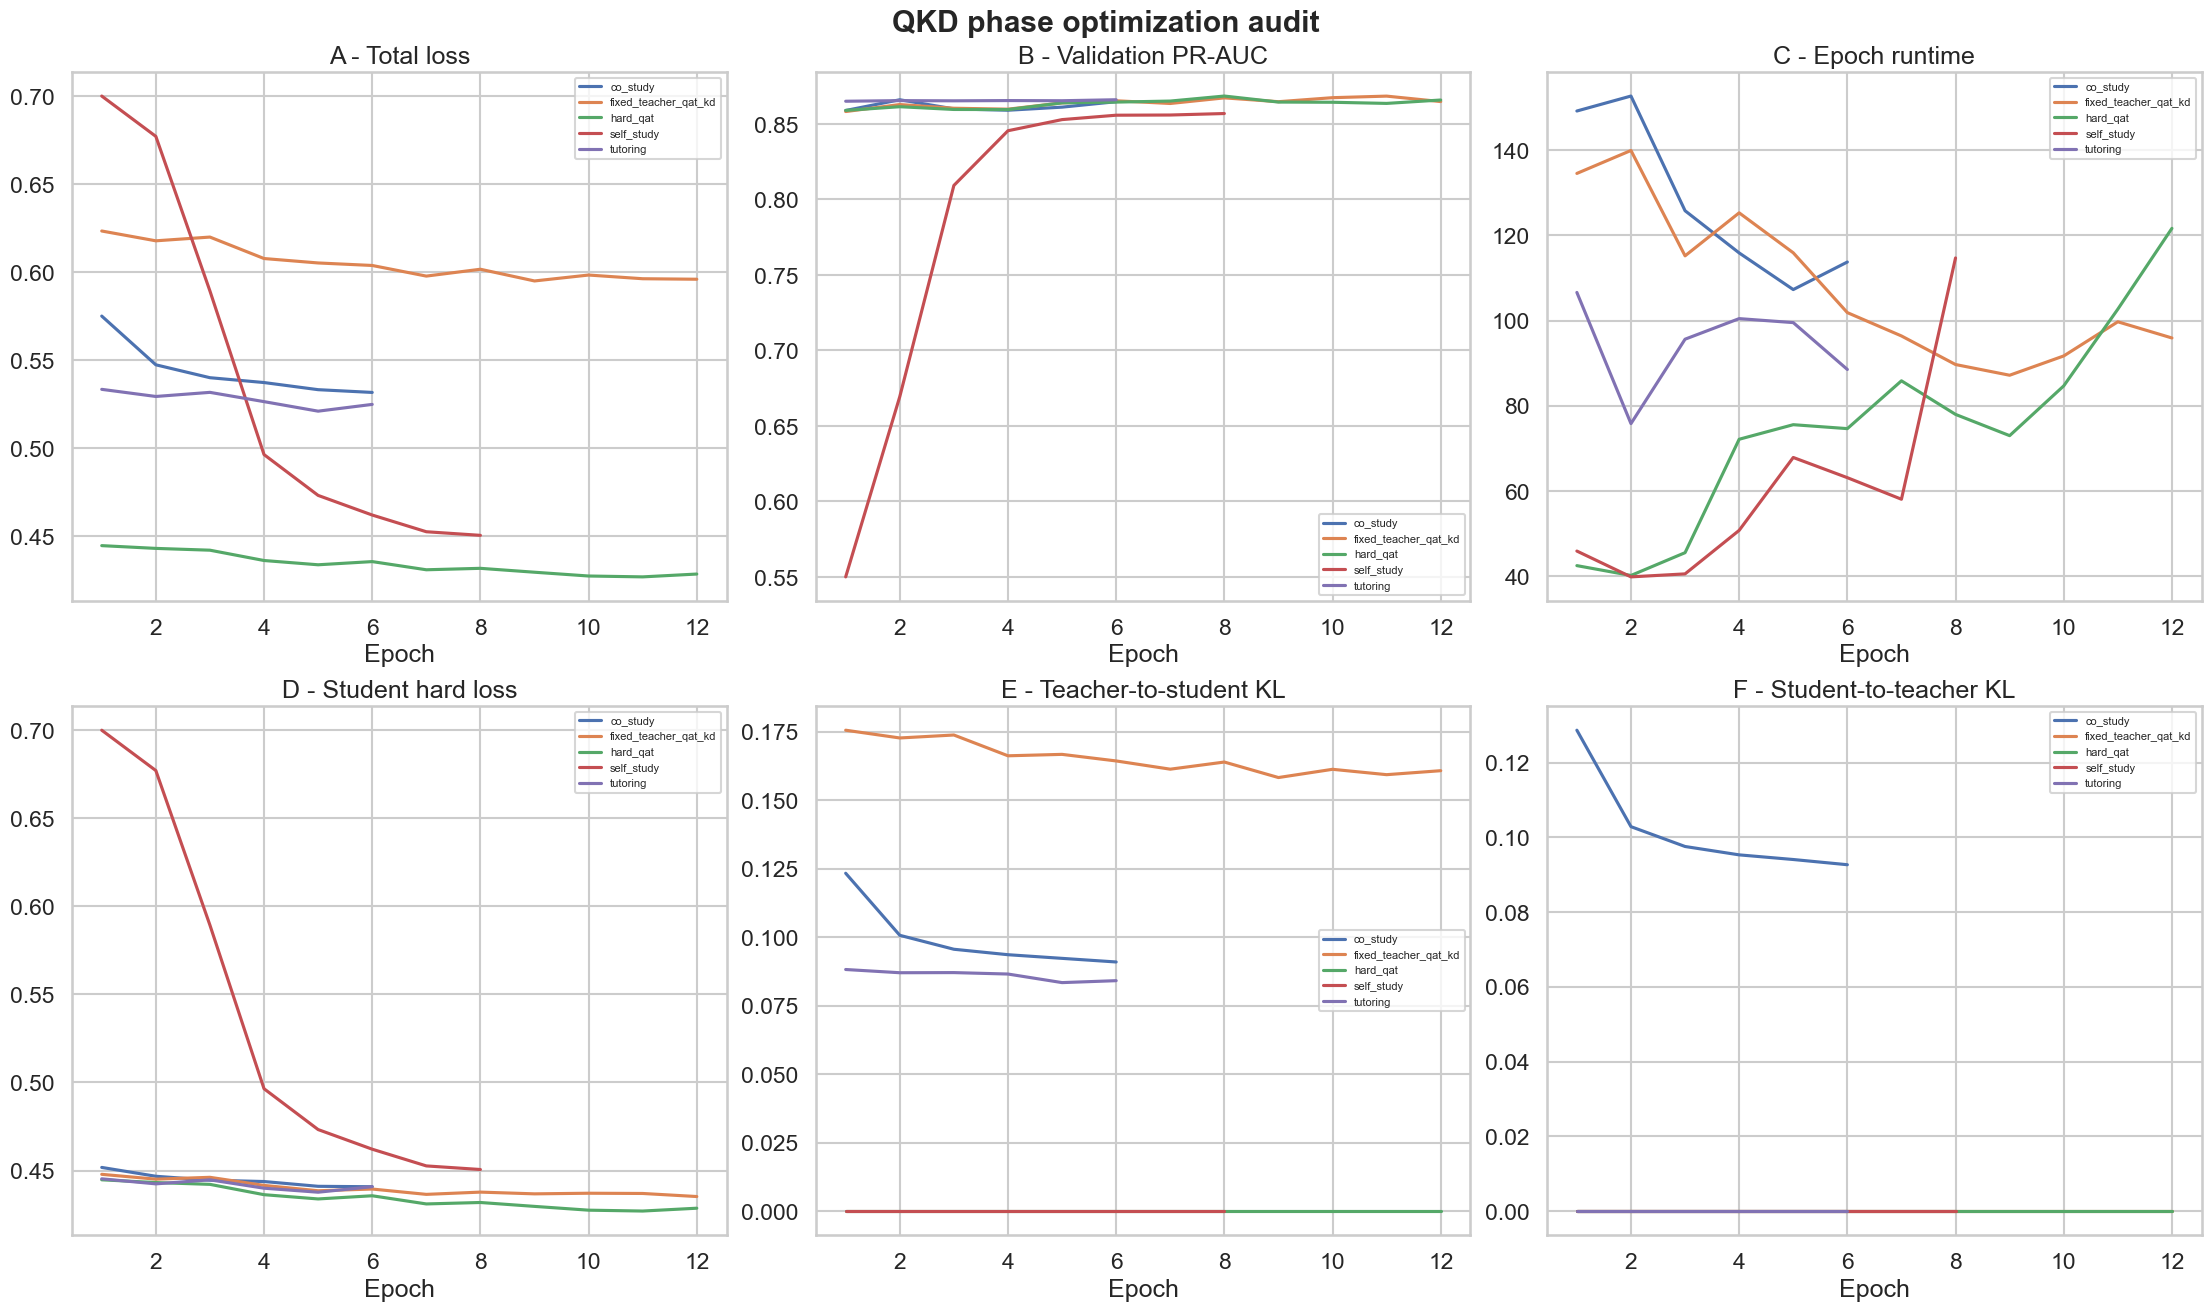

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13), constrained_layout=True)
for name, frame in history.groupby("run"):
    axes[0, 0].plot(frame.epoch_index, frame.loss, label=name)
    axes[0, 1].plot(frame.epoch_index, frame.val_pr_auc, label=name)
    axes[0, 2].plot(frame.epoch_index, frame.epoch_seconds, label=name)
    axes[1, 0].plot(frame.epoch_index, frame.student_hard_loss, label=name)
    axes[1, 1].plot(frame.epoch_index, frame.student_kd_loss, label=name)
    axes[1, 2].plot(frame.epoch_index, frame.reverse_kd_loss, label=name)
titles = ["A - Total loss", "B - Validation PR-AUC", "C - Epoch runtime", "D - Student hard loss", "E - Teacher-to-student KL", "F - Student-to-teacher KL"]
for axis, title in zip(axes.flat, titles): axis.set_title(title); axis.set_xlabel("Epoch"); axis.legend(fontsize=8)
fig.suptitle("QKD phase optimization audit", fontweight="bold")
fig.savefig(FIGURE_DIR / "qkd_training_audit.png", dpi=180)
plt.show()

In [41]:
def teacher_probabilities(model, frame):
    dataset = tf.data.Dataset.from_tensor_slices((frame.image_path.astype(str), frame.label.astype("float32")))
    dataset = dataset.map(
        lambda path, label: (tf.image.resize_with_pad(decode_rgb(path), *TEACHER_SIZE, antialias=True), label),
        num_parallel_calls=AUTOTUNE,
    ).batch(BATCH_SIZE)
    labels = np.concatenate([np.asarray(y).reshape(-1) for _, y in dataset]).astype(int)
    probability = np.asarray(model.predict(dataset, verbose=0)).reshape(-1)
    return labels, probability

adapted_teacher = build_float_teacher()
adapted_teacher.load_weights(CO_TEACHER)
teacher_rows = []
for name, model in {"teacher_original": teacher_original, "teacher_adapted": adapted_teacher}.items():
    labels, probability = teacher_probabilities(model, splits["val"])
    threshold = select_threshold(labels, probability, objective="f1", minimum_recall=.8)["threshold"]
    teacher_rows.append({"model": name, **classification_metrics(labels, probability, threshold)})
teacher_adaptation = pd.DataFrame(teacher_rows)
teacher_adaptation.to_csv(REPORT_DIR / "teacher_adaptation.csv", index=False)
display(teacher_adaptation)

,model,samples,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,confusion_matrix,positive_prevalence,predicted_positive_rate
0,teacher_original,2000,0.365,0.8535,0.843874,0.863498,0.853573,0.932490,0.941853,0.843719,"[[853, 158], [135, 854]]",0.4945,0.506
1,teacher_adapted,2000,0.440,0.8485,0.836935,0.861476,0.849028,0.930903,0.938848,0.835806,"[[845, 166], [137, 852]]",0.4945,0.509


## 8 - PTQ and QAT full-INT8 export

In [42]:
val_dataset = make_student_eval_dataset(splits["val"])
test_dataset = make_student_eval_dataset(splits["test"])

def representative_dataset():
    emitted = 0
    for images, _ in val_dataset:
        for image in images:
            yield [image.numpy()[None].astype(np.float32)]
            emitted += 1
            if emitted >= int(config["quantization"]["representative_samples"]): return

def load_qat(weights_path):
    model = build_qat_student(); model.load_weights(weights_path); return model

export_paths = {
    "ptq_int8": MODEL_DIR / config["export"]["ptq_filename"],
    "hard_qat_int8": MODEL_DIR / config["export"]["hard_qat_filename"],
    "fixed_teacher_qat_kd_int8": MODEL_DIR / config["export"]["fixed_teacher_filename"],
    "qkd_full_int8": MODEL_DIR / config["export"]["qkd_filename"],
}

if RUN_EXPORT:
    convert_full_integer(float_student, representative_dataset(), export_paths["ptq_int8"])
    for name, weights in weight_paths.items():
        export_name = {"hard_qat": "hard_qat_int8", "fixed_teacher_qat_kd": "fixed_teacher_qat_kd_int8", "qkd_full": "qkd_full_int8"}[name]
        convert_full_integer(load_qat(weights), representative_dataset(), export_paths[export_name])
for path in export_paths.values(): assert path.exists(), path

INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmp3erkjost/assets


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmp3erkjost/assets
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1791175193.220918 7700906 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791175193.220943 7700906 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1791175193.261172 7700906 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpnrkxrnzj/assets


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpnrkxrnzj/assets
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1791175213.341540 7700906 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791175213.341561 7700906 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpmgull5pp/assets


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmpmgull5pp/assets
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1791175235.673614 7700906 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791175235.673624 7700906 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmp81izzqg5/assets


INFO:tensorflow:Assets written to: /var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/tmp81izzqg5/assets
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1791175259.388570 7700906 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1791175259.388586 7700906 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [43]:
def integer_audit(path):
    interpreter = tf.lite.Interpreter(model_path=str(path)); interpreter.allocate_tensors()
    info = inspect_tflite(path)
    tensors = interpreter.get_tensor_details()
    float_tensors = [detail["name"] for detail in tensors if np.dtype(detail["dtype"]) == np.float32]
    info.update({
        "sha256": sha256_file(path),
        "gzip_bytes": len(gzip.compress(Path(path).read_bytes(), compresslevel=9)),
        "float_tensor_count": len(float_tensors),
        "float_tensors": float_tensors,
        "integer_only": len(float_tensors) == 0 and info["input"]["dtype"] == "int8" and info["output"]["dtype"] == "int8",
    })
    return info

export_info = {name: integer_audit(path) for name, path in export_paths.items()}
(REPORT_DIR / "export_info.json").write_text(json.dumps(export_info, indent=2), encoding="utf-8")
display(pd.DataFrame([
    {"model": name, "bytes": info["size_bytes"], "gzip_bytes": info["gzip_bytes"], "integer_only": info["integer_only"], "operators": ", ".join(info["operators"])}
    for name, info in export_info.items()
]))

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


,model,bytes,gzip_bytes,integer_only,operators
0,ptq_int8,303304,220234,True,"ADD, CONV_2D, DEPTHWISE_CONV_2D, FULLY_CONNECT..."
1,hard_qat_int8,320952,210607,True,"ADD, CONV_2D, DEPTHWISE_CONV_2D, FULLY_CONNECT..."
2,fixed_teacher_qat_kd_int8,320952,210613,True,"ADD, CONV_2D, DEPTHWISE_CONV_2D, FULLY_CONNECT..."
3,qkd_full_int8,320952,210619,True,"ADD, CONV_2D, DEPTHWISE_CONV_2D, FULLY_CONNECT..."


## 9 - Frozen-test comparison and paired uncertainty

In [44]:
def labels_from_dataset(dataset): return np.concatenate([np.asarray(y).reshape(-1) for _, y in dataset]).astype(int)

def predict_keras(model, dataset): return np.asarray(model.predict(dataset, verbose=0)).reshape(-1)

def predict_tflite(path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(path)); interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]; out = interpreter.get_output_details()[0]
    in_scale, in_zero = inp["quantization"]; out_scale, out_zero = out["quantization"]
    outputs = []
    for images, _ in dataset:
        for image in np.asarray(images):
            quantized = np.clip(np.round(image / in_scale + in_zero), -128, 127).astype(np.int8)[None]
            interpreter.set_tensor(inp["index"], quantized); interpreter.invoke()
            raw = interpreter.get_tensor(out["index"])[0, 0]
            outputs.append((float(raw) - out_zero) * out_scale)
    return np.asarray(outputs)

val_labels = labels_from_dataset(val_dataset); test_labels = labels_from_dataset(test_dataset)
probabilities = {"float_champion": predict_keras(float_student, test_dataset)}
validation_probabilities = {"float_champion": predict_keras(float_student, val_dataset)}
for name, path in export_paths.items():
    validation_probabilities[name] = predict_tflite(path, val_dataset)
    probabilities[name] = predict_tflite(path, test_dataset)

quality_rows = []
thresholds = {}
for name, test_probability in probabilities.items():
    threshold = select_threshold(
        val_labels, validation_probabilities[name],
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=config["evaluation"]["minimum_recall"],
        false_positive_cost=config["evaluation"]["false_positive_cost"],
        false_negative_cost=config["evaluation"]["false_negative_cost"],
    )["threshold"]
    metrics = classification_metrics(test_labels, test_probability, threshold)
    metrics["ece_10"] = expected_calibration_error(test_labels, test_probability)
    quality_rows.append({"model": name, **metrics}); thresholds[name] = float(threshold)
quality = pd.DataFrame(quality_rows)
quality.to_csv(REPORT_DIR / "quality_comparison.csv", index=False)
(REPORT_DIR / "validation_thresholds.json").write_text(json.dumps(thresholds, indent=2), encoding="utf-8")
display(quality)

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,samples,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,confusion_matrix,positive_prevalence,predicted_positive_rate,ece_10
0,float_champion,2000,0.385,0.7815,0.777551,0.776758,0.777155,0.862603,0.865103,0.786065,"[[801, 218], [219, 762]]",0.4905,0.4900,0.039434
1,ptq_int8,2000,0.275,0.7615,0.745614,0.779817,0.762332,0.853138,0.856849,0.743867,"[[758, 261], [216, 765]]",0.4905,0.5130,0.098125
2,hard_qat_int8,2000,0.010,0.4905,0.490500,1.000000,0.658168,0.547356,0.522209,0.000000,"[[0, 1019], [0, 981]]",0.4905,1.0000,0.425457
3,fixed_teacher_qat_kd_int8,2000,0.025,0.4975,0.493933,0.995923,0.660358,0.544842,0.525732,0.017664,"[[18, 1001], [4, 977]]",0.4905,0.9890,0.399563
4,qkd_full_int8,2000,0.050,0.4960,0.493144,0.989806,0.658305,0.538105,0.522336,0.020608,"[[21, 998], [10, 971]]",0.4905,0.9845,0.374750


In [45]:
qat_keras_probabilities = {}
parity_rows = []
for name, weights in weight_paths.items():
    export_name = {"hard_qat": "hard_qat_int8", "fixed_teacher_qat_kd": "fixed_teacher_qat_kd_int8", "qkd_full": "qkd_full_int8"}[name]
    keras_probability = predict_keras(load_qat(weights), test_dataset)
    qat_keras_probabilities[name] = keras_probability
    int8_probability = probabilities[export_name]
    parity_rows.append({
        "model": export_name,
        "qat_keras_to_tflite_mae": float(np.mean(np.abs(keras_probability - int8_probability))),
        "maximum_absolute_error": float(np.max(np.abs(keras_probability - int8_probability))),
    })
parity = pd.DataFrame(parity_rows)
parity.to_csv(REPORT_DIR / "qat_to_tflite_parity.csv", index=False)
display(parity)

,model,qat_keras_to_tflite_mae,maximum_absolute_error
0,hard_qat_int8,0.419252,0.961283
1,fixed_teacher_qat_kd_int8,0.401152,0.955954
2,qkd_full_int8,0.363890,0.930247


In [46]:
rng = np.random.default_rng(SEED); indices = np.arange(len(test_labels))
records = []
for iteration in range(int(config["evaluation"]["bootstrap_samples"])):
    draw = rng.choice(indices, len(indices), replace=True); labels = test_labels[draw]
    hard = probabilities["hard_qat_int8"][draw]; full = probabilities["qkd_full_int8"][draw]
    records.append({
        "iteration": iteration,
        "pr_auc_delta": average_precision_score(labels, full) - average_precision_score(labels, hard),
        "f1_delta": f1_score(labels, full >= thresholds["qkd_full_int8"]) - f1_score(labels, hard >= thresholds["hard_qat_int8"]),
    })
bootstrap = pd.DataFrame(records); bootstrap.to_csv(REPORT_DIR / "paired_bootstrap.csv", index=False)
bootstrap_summary = pd.DataFrame([
    {"metric": metric, "mean": bootstrap[metric].mean(), "ci_low": bootstrap[metric].quantile(.025), "ci_high": bootstrap[metric].quantile(.975), "probability_positive": (bootstrap[metric] > 0).mean()}
    for metric in ("pr_auc_delta", "f1_delta")
])
bootstrap_summary.to_csv(REPORT_DIR / "bootstrap_summary.csv", index=False)
display(bootstrap_summary)

,metric,mean,ci_low,ci_high,probability_positive
0,pr_auc_delta,0.000202,-0.020975,0.021355,0.511
1,f1_delta,0.000082,-0.003724,0.003486,0.529


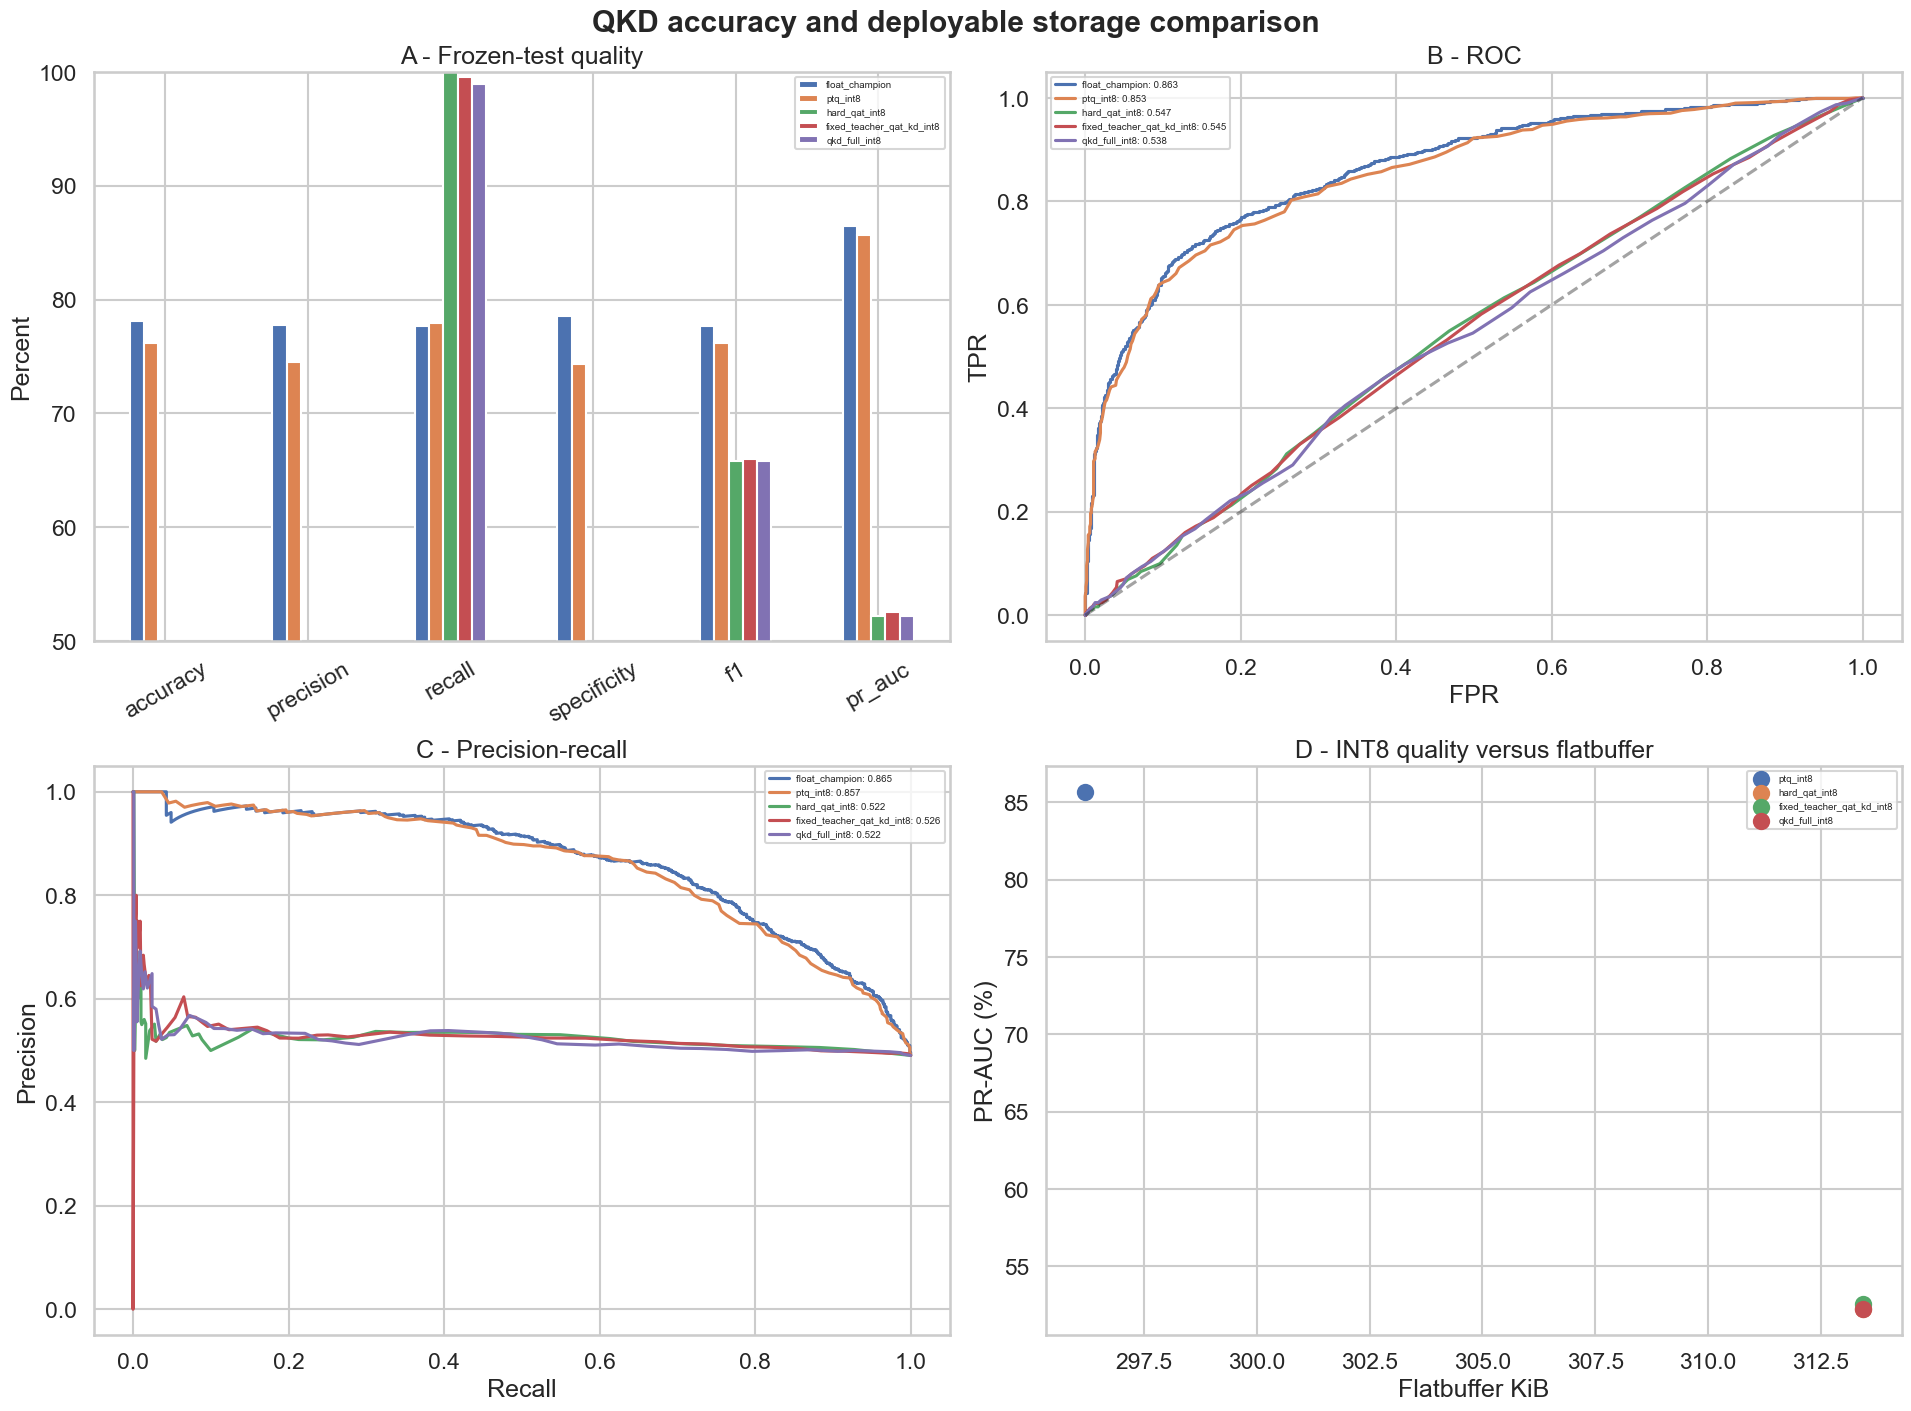

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(19, 14), constrained_layout=True)
metrics = ["accuracy", "precision", "recall", "specificity", "f1", "pr_auc"]
(quality.set_index("model")[metrics].T * 100).plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set(title="A - Frozen-test quality", ylabel="Percent", ylim=(50, 100)); axes[0, 0].tick_params(axis="x", rotation=30)
for name in probabilities:
    fp, tp, _ = roc_curve(test_labels, probabilities[name]); precision, recall, _ = precision_recall_curve(test_labels, probabilities[name])
    row = quality.set_index("model").loc[name]
    axes[0, 1].plot(fp, tp, label=f"{name}: {row.roc_auc:.3f}")
    axes[1, 0].plot(recall, precision, label=f"{name}: {row.pr_auc:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", alpha=.4); axes[0, 1].set(title="B - ROC", xlabel="FPR", ylabel="TPR")
axes[1, 0].set(title="C - Precision-recall", xlabel="Recall", ylabel="Precision")
for name, info in export_info.items():
    row = quality.set_index("model").loc[name]
    axes[1, 1].scatter(info["size_bytes"] / 1024, row.pr_auc * 100, s=120, label=name)
axes[1, 1].set(title="D - INT8 quality versus flatbuffer", xlabel="Flatbuffer KiB", ylabel="PR-AUC (%)")
for axis in axes.flat: axis.legend(fontsize=7)
fig.suptitle("QKD accuracy and deployable storage comparison", fontweight="bold")
fig.savefig(FIGURE_DIR / "qkd_quality_efficiency_dashboard.png", dpi=180)
plt.show()

## 10 - Quantizer ranges and saturation-risk diagnostics

In [48]:
quantizer_frames = []
for name, weights in weight_paths.items():
    model = load_qat(weights); frame = quantizer_inventory(model); frame["model"] = name; quantizer_frames.append(frame)
quantizers = pd.concat(quantizer_frames, ignore_index=True)
quantizers.to_csv(REPORT_DIR / "final_quantizer_inventory.csv", index=False)
display(quantizers.groupby("model")[["minimum", "maximum"]].agg(["min", "median", "max"]))

minimum                           maximum            \
                             min    median         max         min    median   
model                                                                          
fixed_teacher_qat_kd -152.204132 -0.002406  136.915665 -152.204132  0.079686   
hard_qat             -151.421753 -0.007414  137.484879 -151.421753  0.080121   
qkd_full             -151.748215 -0.007414  136.688858 -151.748215  0.079194   

                                  
                             max  
model                             
fixed_teacher_qat_kd  136.915665  
hard_qat              137.484879  
qkd_full              136.688858

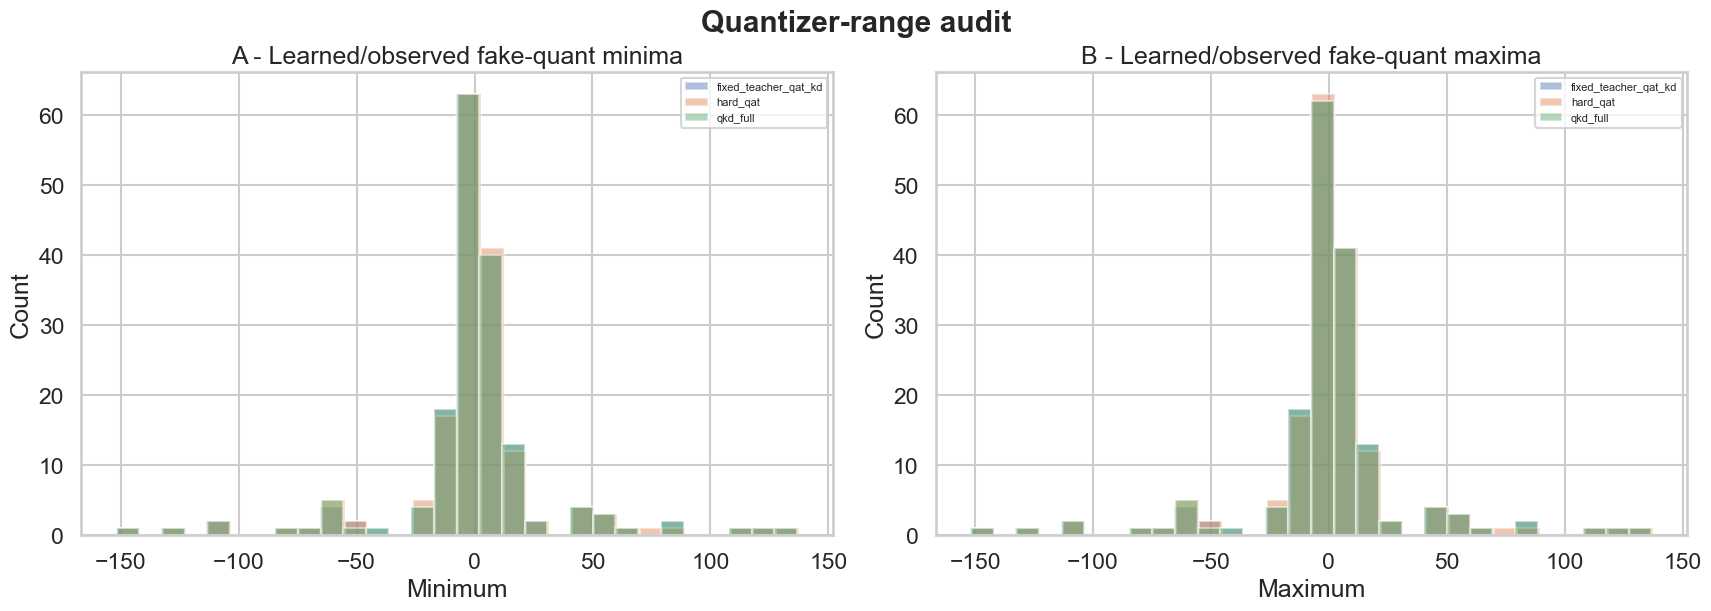

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
for name, frame in quantizers.groupby("model"):
    axes[0].hist(frame.minimum, bins=30, alpha=.45, label=name)
    axes[1].hist(frame.maximum, bins=30, alpha=.45, label=name)
axes[0].set(title="A - Learned/observed fake-quant minima", xlabel="Minimum", ylabel="Count")
axes[1].set(title="B - Learned/observed fake-quant maxima", xlabel="Maximum", ylabel="Count")
for axis in axes: axis.legend(fontsize=8)
fig.suptitle("Quantizer-range audit", fontweight="bold")
fig.savefig(FIGURE_DIR / "qkd_quantizer_ranges.png", dpi=180)
plt.show()

## 11 - Desktop latency, gates, and physical-device hand-off

In [50]:
def benchmark_tflite(path, sample):
    interpreter = tf.lite.Interpreter(model_path=str(path)); interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]; scale, zero = inp["quantization"]
    quantized = np.clip(np.round(sample / scale + zero), -128, 127).astype(np.int8)[None]
    for _ in range(int(config["evaluation"]["desktop_latency_warmup"])):
        interpreter.set_tensor(inp["index"], quantized); interpreter.invoke()
    values = []
    for _ in range(int(config["evaluation"]["desktop_latency_runs"])):
        start = time.perf_counter_ns(); interpreter.set_tensor(inp["index"], quantized); interpreter.invoke()
        values.append((time.perf_counter_ns() - start) / 1e6)
    return {"mean_ms": np.mean(values), "median_ms": np.median(values), "p95_ms": np.quantile(values, .95), "minimum_ms": np.min(values)}

sample_image = next(iter(test_dataset))[0][0].numpy()
latency = pd.DataFrame([{"model": name, **benchmark_tflite(path, sample_image)} for name, path in export_paths.items()])
latency.to_csv(REPORT_DIR / "desktop_latency.csv", index=False)
display(latency)

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,mean_ms,median_ms,p95_ms,minimum_ms
0,ptq_int8,0.195600,0.195500,0.207444,0.182916
1,hard_qat_int8,0.362528,0.363084,0.372320,0.340666
2,fixed_teacher_qat_kd_int8,0.359665,0.362437,0.369441,0.340667
3,qkd_full_int8,0.360830,0.362458,0.371004,0.341292


In [51]:
q = quality.set_index("model"); hard = q.loc["hard_qat_int8"]; full = q.loc["qkd_full_int8"]
float_row = q.loc["float_champion"]
full_parity = parity.set_index("model").loc["qkd_full_int8"]
gates = {
    "pr_auc_gain_over_hard_qat": bool(full.pr_auc >= hard.pr_auc + config["acceptance_gate"]["minimum_pr_auc_gain_over_hard_qat"]),
    "f1_retained_vs_hard_qat": bool(full.f1 >= hard.f1 - config["acceptance_gate"]["maximum_f1_drop_from_hard_qat"]),
    "specificity_retained_vs_hard_qat": bool(full.specificity >= hard.specificity - config["acceptance_gate"]["maximum_specificity_drop_from_hard_qat"]),
    "float_pr_auc_retained": bool(full.pr_auc >= float_row.pr_auc - config["acceptance_gate"]["maximum_pr_auc_drop_from_float"]),
    "qat_tflite_parity": bool(full_parity.qat_keras_to_tflite_mae <= config["acceptance_gate"]["maximum_float_to_int8_probability_mae"]),
    "integer_only": bool(export_info["qkd_full_int8"]["integer_only"]),
}
gates["accepted_desktop"] = all(gates.values())
gates["eligible_for_device"] = gates["accepted_desktop"]
(REPORT_DIR / "acceptance_gates.json").write_text(json.dumps(gates, indent=2), encoding="utf-8")
display(pd.Series(gates))

pr_auc_gain_over_hard_qat            True
f1_retained_vs_hard_qat              True
specificity_retained_vs_hard_qat     True
float_pr_auc_retained               False
qat_tflite_parity                   False
integer_only                         True
accepted_desktop                    False
eligible_for_device                 False
dtype: bool

In [52]:
hardware = pd.DataFrame([
    {
        "model": name,
        "parameters": static_profile["parameters"],
        "estimated_macs_batch1": static_profile["estimated_macs_batch1"],
        "estimated_peak_int8_activation_bytes": static_profile["peak_live_activation_int8_bytes_batch1_hypothetical"],
        "flatbuffer_bytes": info["size_bytes"],
        "desktop_median_ms": latency.set_index("model").loc[name, "median_ms"],
        "esp32_cam_invoke_ms": np.nan,
        "esp32_s3_invoke_ms": np.nan,
        "measured_tensor_arena_bytes": np.nan,
        "evidence": "static estimate + desktop measurement; physical fields pending",
    }
    for name, info in export_info.items()
])
hardware.to_csv(REPORT_DIR / "hardware_summary.csv", index=False)
display(hardware)

,model,parameters,estimated_macs_batch1,estimated_peak_int8_activation_bytes,flatbuffer_bytes,desktop_median_ms,esp32_cam_invoke_ms,esp32_s3_invoke_ms,measured_tensor_arena_bytes,evidence
0,ptq_int8,218801,10487648,160336,303304,0.195500,NaN,NaN,NaN,static estimate + desktop measurement; physica...
1,hard_qat_int8,218801,10487648,160336,320952,0.363084,NaN,NaN,NaN,static estimate + desktop measurement; physica...
2,fixed_teacher_qat_kd_int8,218801,10487648,160336,320952,0.362437,NaN,NaN,NaN,static estimate + desktop measurement; physica...
3,qkd_full_int8,218801,10487648,160336,320952,0.362458,NaN,NaN,NaN,static estimate + desktop measurement; physica...


Desktop latency is a conversion sanity check, not an ESP32 prediction. If and only if
`eligible_for_device` is true, flash the QKD INT8 artifact with camera flash disabled and measure
capture, preprocessing, invoke, postprocessing, tensor arena, SRAM, PSRAM, flash, and sustained FPS
separately on ESP32-CAM and ESP32-S3.

## 12 - Final reports and decision

In [53]:
def json_default(value):
    if isinstance(value, np.integer): return int(value)
    if isinstance(value, np.floating): return float(value)
    if isinstance(value, np.ndarray): return value.tolist()
    if isinstance(value, Path): return str(value)
    raise TypeError(type(value).__name__)

summary = {
    "experiment": config["project"]["name"],
    "paper_method": {"phases": ["self-studying", "co-studying", "tutoring"], "temperature": TEMPERATURE, "student_loss": "CE + T^2 KL(teacher||student)", "teacher_loss": "CE + T^2 KL(student||teacher)"},
    "contract": contract,
    "quality": quality.to_dict("records"),
    "bootstrap": bootstrap_summary.to_dict("records"),
    "teacher_adaptation": teacher_adaptation.to_dict("records"),
    "parity": parity.to_dict("records"),
    "export": export_info,
    "hardware": hardware.to_dict("records"),
    "gates": gates,
    "physical_profile_complete": False,
}
(REPORT_DIR / "experiment_summary.json").write_text(json.dumps(summary, indent=2, default=json_default), encoding="utf-8")

lines = [
    "# Quantization-aware Knowledge Distillation report", "",
    f"- Full QKD desktop accepted: **{gates['accepted_desktop']}**",
    f"- Eligible for physical profiling: **{gates['eligible_for_device']}**",
    "- Physical profiling complete: **False**", "",
    "## Frozen-test quality", "", quality.to_markdown(index=False), "",
    "## Paired bootstrap: full QKD minus hard QAT", "", bootstrap_summary.to_markdown(index=False), "",
    "## Teacher adaptation", "", teacher_adaptation.to_markdown(index=False), "",
    "## QAT-to-TFLite parity", "", parity.to_markdown(index=False), "",
    "## Acceptance gates", "", pd.Series(gates, name="passed").to_markdown(), "",
]
(REPORT_DIR / "QKD_REPORT.md").write_text("\n".join(lines), encoding="utf-8")
print(REPORT_DIR / "QKD_REPORT.md")

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/qkd_int8_student_120/reports/QKD_REPORT.md


## Decision guide

- **PTQ matches float:** QKD may be scientifically interesting but is not required for deployment.
- **Hard QAT beats PTQ:** quantization simulation helps; use hard QAT as the causal deployment baseline.
- **Fixed-teacher KD beats hard QAT:** teacher supervision helps the quantized student.
- **Full QKD beats fixed-teacher KD:** co-studying created a useful quantization-aware teacher, validating the paper's distinctive contribution.
- **QKD loses specificity or fails bootstrap:** do not deploy it even if a single scalar metric rises.
- **Desktop gates pass:** proceed to physical ESP32 measurements; do not infer device speed from desktop latency.